# 04 · Backprop for Hidden Layers

**Goal:** propagate the error signal backwards through an arbitrary number of layers.

The recursion (row-major batch convention):

$$\delta^{[l]} = \Big(\delta^{[l+1]}\,\big(W^{[l+1]}\big)^{\!\top}\Big)\odot g'^{[l]}\!\big(Z^{[l]}\big)$$

and for **every** layer

$$\frac{\partial\mathcal L}{\partial W^{[l]}}=\big(A^{[l-1]}\big)^{\!\top}\delta^{[l]},\qquad \frac{\partial\mathcal L}{\partial b^{[l]}}=\sum_n \delta^{[l]}_{n,:}$$

Read it as: *"take the error from the layer above, send it back through the weights, and gate it by how sensitive this layer's activation was."*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(2)

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

# activation & derivative pairs (derivative takes Z)
ACT = {
    "relu":    (lambda z: np.maximum(0, z),           lambda z: (z > 0).astype(float)),
    "tanh":    (np.tanh,                              lambda z: 1 - np.tanh(z) ** 2),
    "sigmoid": (lambda z: 1 / (1 + np.exp(-z)),       lambda z: (lambda s: s * (1 - s))(1 / (1 + np.exp(-z)))),
}

## 1. Forward (with cache) and backward for L layers

In [2]:
def init_params(sizes, rng, scheme="he"):
    ps = []
    for i, o in zip(sizes[:-1], sizes[1:]):
        scale = np.sqrt(2.0 / i) if scheme == "he" else np.sqrt(1.0 / i)   # "xavier-like"
        ps.append((rng.normal(0, scale, (i, o)), np.zeros(o)))
    return ps

def forward(X, params, act="relu"):
    g, _ = ACT[act]
    A, L = X, len(params)
    cache = [(None, X)]                          # cache[l] = (Z^[l], A^[l]), l = 0..L
    for l, (W, b) in enumerate(params, start=1):
        Z = A @ W + b
        A = softmax(Z) if l == L else g(Z)
        cache.append((Z, A))
    return A, cache

def cross_entropy(P, Y):
    return -np.sum(Y * np.log(P + 1e-12)) / Y.shape[0]

def backward(Y, params, cache, act="relu", verbose=False):
    _, gprime = ACT[act]
    N, L = Y.shape[0], len(params)
    grads = [None] * L
    delta = (cache[-1][1] - Y) / N               # output layer: (P - Y) / N
    for l in range(L, 0, -1):                    # l = L, L-1, ..., 1
        A_prev = cache[l - 1][1]
        W, _ = params[l - 1]
        grads[l - 1] = (A_prev.T @ delta, delta.sum(axis=0))
        if verbose:
            print(f"layer {l}: delta{delta.shape}  dW{grads[l-1][0].shape}")
        if l > 1:
            Z_prev = cache[l - 1][0]
            delta = (delta @ W.T) * gprime(Z_prev)   # send back through W, gate by g'
    return grads

# tiny demonstration of the shapes flowing backwards
sizes = [6, 5, 4, 3]
params = init_params(sizes, rng)
X = rng.normal(size=(7, 6)); Y = np.eye(3)[rng.integers(0, 3, 7)]
P, cache = forward(X, params)
_ = backward(Y, params, cache, verbose=True)

layer 3: delta(7, 3)  dW(4, 3)
layer 2: delta(7, 4)  dW(5, 4)
layer 1: delta(7, 5)  dW(6, 5)


## 2. Gradient check *every* parameter of a deeper network
We use `tanh` for the check because ReLU has a kink at 0 which can confuse finite differences.

In [3]:
def numerical_grad(f, x, eps=1e-6):
    g = np.zeros_like(x)
    it = np.nditer(x, flags=["multi_index"])
    for _ in it:
        idx = it.multi_index
        old = x[idx]
        x[idx] = old + eps; fp = f()
        x[idx] = old - eps; fm = f()
        x[idx] = old
        g[idx] = (fp - fm) / (2 * eps)
    return g

def rel_err(a, b):
    return np.linalg.norm(a - b) / (np.linalg.norm(a) + np.linalg.norm(b) + 1e-12)

sizes = [6, 8, 7, 5, 3]                          # 3 hidden layers
params = init_params(sizes, rng, scheme="xavier")
X = rng.normal(size=(9, 6)); Y = np.eye(3)[rng.integers(0, 3, 9)]

P, cache = forward(X, params, "tanh")
grads = backward(Y, params, cache, "tanh")
loss = lambda: cross_entropy(forward(X, params, "tanh")[0], Y)

for l, ((W, b), (dW, db)) in enumerate(zip(params, grads), start=1):
    eW = rel_err(dW, numerical_grad(loss, W))
    eb = rel_err(db, numerical_grad(loss, b))
    print(f"layer {l}:  dW rel.err = {eW:.2e}   db rel.err = {eb:.2e}")

layer 1:  dW rel.err = 6.99e-10   db rel.err = 1.43e-09
layer 2:  dW rel.err = 7.42e-10   db rel.err = 7.07e-10
layer 3:  dW rel.err = 6.74e-10   db rel.err = 6.15e-10
layer 4:  dW rel.err = 6.11e-10   db rel.err = 4.45e-10


## 3. The vanishing-gradient problem, measured
Each backward step multiplies by $g'(z)$. For the sigmoid, $g'\le 0.25$, so after many layers the signal is crushed. ReLU (derivative 1 for $z>0$) with He initialisation keeps the scale healthy.

sigmoid + Xavier   ||dW|| layer1 = 1.74e-07   layer11 = 9.19e-01
tanh + Xavier      ||dW|| layer1 = 1.05e-01   layer11 = 8.47e-02
ReLU + He          ||dW|| layer1 = 8.98e-01   layer11 = 5.25e+00


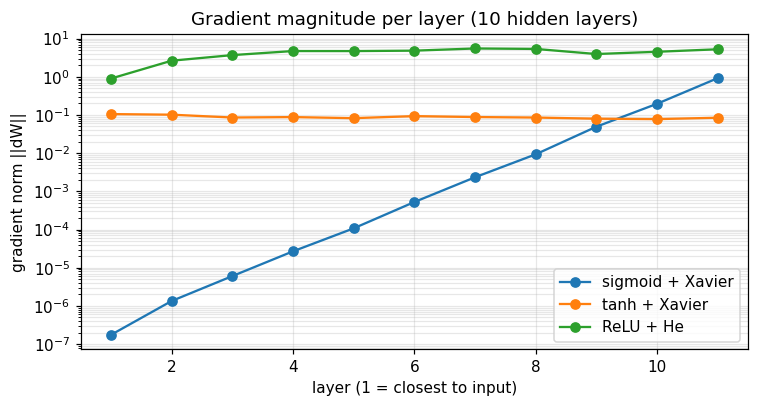

In [4]:
def layerwise_grad_norms(act, scheme, depth=10, width=50, N=256, n_cls=5, seed=0):
    r = np.random.default_rng(seed)
    sizes = [width] + [width] * depth + [n_cls]
    ps = init_params(sizes, r, scheme)
    X = r.normal(size=(N, width)); Y = np.eye(n_cls)[r.integers(0, n_cls, N)]
    P, c = forward(X, ps, act)
    gr = backward(Y, ps, c, act)
    return [np.linalg.norm(dW) for dW, _ in gr]

runs = {
    "sigmoid + Xavier": ("sigmoid", "xavier"),
    "tanh + Xavier":    ("tanh",    "xavier"),
    "ReLU + He":        ("relu",    "he"),
}
plt.figure(figsize=(7, 3.8))
for name, (a, s) in runs.items():
    norms = layerwise_grad_norms(a, s)
    plt.semilogy(range(1, len(norms) + 1), norms, "o-", label=name)
    print(f"{name:<18} ||dW|| layer1 = {norms[0]:.2e}   layer{len(norms)} = {norms[-1]:.2e}")
plt.xlabel("layer (1 = closest to input)"); plt.ylabel("gradient norm ||dW||")
plt.title("Gradient magnitude per layer (10 hidden layers)")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

## 4. Take-aways
* Backprop = **reverse-mode automatic differentiation** specialised to a chain of layers: one forward sweep (store $Z,A$), one backward sweep.
* Cost of backward ≈ 2× the cost of forward (two matmuls per layer: one for $dW$, one for $\delta$).
* Initialisation and activation choice decide whether gradients survive the trip back.

### Try it yourself
1. Add a `leaky_relu` entry to `ACT` and repeat the gradient check.
2. Print `||delta||` per layer (not `||dW||`) for the sigmoid network. Do they decay at the same rate?
3. Run the vanishing-gradient experiment with `depth=30`. At what depth does ReLU + He start to *explode* instead?